# Data load

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math
import scanpy as sc
from adjustText import adjust_text

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects

# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [2]:
from module.misc import sample_name_import

name_dir = "circa-SD"
# name_dir = "all-samples-C123"
# name_dir = 'all-samples'

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [3]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [4]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [16]:
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

In [ ]:
df.to_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [6]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [7]:
df.columns

Index(['A1cf', 'A2m', 'Aatf', 'Abca1', 'Abca13', 'Abca3', 'Abca4', 'Abca7',
       'Abca8a', 'Abca8b',
       ...
       'ZT', 'run', 'cell_type_final', 'region_automap_name',
       'transcript_counts', 'cell_class', 'circascore', 'x_centroid',
       'y_centroid', 'Neurotransmitter'],
      dtype='object', length=4667)

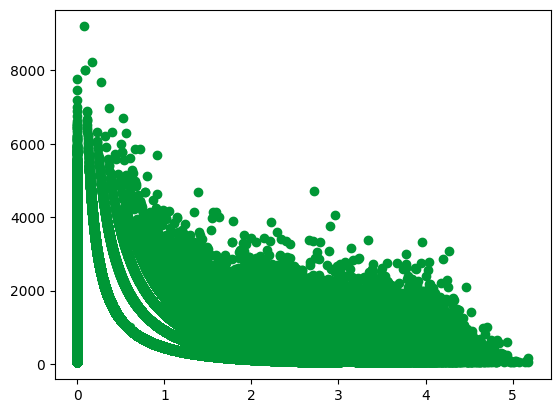

In [8]:
plt.scatter(df['Gfap'], df['transcript_counts'])

# Load data

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math
import scanpy as sc
from adjustText import adjust_text

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [26]:
from module.misc import sample_name_import

name_dir = "circa-SD"
# name_dir = "all-samples"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [27]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [28]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [29]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [30]:
## SD dendro order

order_list = ['Oligodendrocyte', 'Microglia', 'Choroid', 'ABC', 'VLMC', 'OB_STR_CTX_Inh_IMN', 'Ependymal', 'Tanycyte', 'OPC', 'Astrocyte', 'Endothelial', 'Pericyte', 'PVH_SO_Glut', 'PVR_Gaba', 'SCH_Gaba', 'MH_Glut', 'TRS_BAC_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut', 'LSX_Gaba', 'CEA_AAA_BST_Gaba', 'STR_PAL_Gaba', 'Sst_Gaba', 'Lamp5_Gaba', 'Vip_Gaba', 'Pvalb_Gaba', 'STR_Gaba', 'RT_ZI_Gaba', 'SI_Gaba', 'ATN_Glut', 'PT_Glut', 'RE_Glut', 'AD_Glut', 'AV_Glut', 'TH_Glut', 'LSX_Glut', 'BST_MPN_Gaba', 'COAa_PAA_MEA_Glut', 'PAL_STR_Gaba_Chol', 'PVT_Glut', 'BST_po_Glut', 'LH_Glut', 'MEA_Glut', 'AHN_Glut', 'LHA_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'DG_Glut', 'CA1_ProS_Glut', 'CA2_FC_IG_Glut', 'CA3_Glut', 'L2_3_IT_CTX_Glut', 'L4_5_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_RSP_Glut', 'L5_ET_CTX_Glut', 'L5_NP_CTX_Glut', 'L6_IT_CTX_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'CLA_EPd_CTX_Glut', 'L2_3_IT_PIR_ENTl_Glut', 'NLOT_Glut']


# Cell Population

In [31]:
grouped = df.groupby(['run','sample','region_automap_name'])['cell_type_final'].value_counts(dropna=True)
grouped.to_csv(f'data/cell_count_region_{name_dir}.csv')

In [32]:
import math
df = pd.read_csv(f'data/cell_count_region_{name_dir}.csv')

df = df[df['count'] > 10]

df_nbcells_av = []
df_nbcells_sem = []
df_nbcells_pct = []

all_regions = df['region_automap_name'].unique()
all_celltypes = df['cell_type_final'].unique()

for region in all_regions:
    dat_av = pd.DataFrame()
    dat_sem = pd.DataFrame()
    dat_pct = pd.DataFrame()
    
    for cell in all_celltypes:
        temp_av = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].mean()
        tempdf = pd.DataFrame(data = {cell : temp_av})
        dat_av = pd.concat([dat_av, tempdf], axis=1)

        temp_percent = df[(df['cell_type_final']== cell)& (df['region_automap_name'] == region) ].groupby('run')['count'].sum() / df[df['region_automap_name'] == region].groupby('run')['count'].sum() * 100
        tempdf = pd.DataFrame(data = {cell : temp_percent}) 
        dat_pct = pd.concat([dat_pct, tempdf], axis=1)  

        temp_sem = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].std() / df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].count()
        tempdf = pd.DataFrame(data = {cell : temp_sem})
        dat_sem = pd.concat([dat_sem, tempdf], axis=1)
    
    df_nbcells_sem.append(dat_sem)
    df_nbcells_av.append(dat_av)
    df_nbcells_pct.append(dat_pct)

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_av[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_sem[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_pct[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

In [33]:
df_average = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', sheet_name=None)
df_std = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', sheet_name=None)
df_pct = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', sheet_name=None)

df_average = {key: value for key, value in sorted(df_average.items())}
df_std = {key: value for key, value in sorted(df_std.items())}
df_pct = {key: value for key, value in sorted(df_pct.items())}


df_average.pop('VLMC')
df_average.pop('Ependymal')
# df_average.pop('CHOR')
# df_average.pop('Tanycyte')

# df_std.pop('Tanycyte')
df_std.pop('VLMC')
# df_std.pop('CHOR')
df_std.pop('Ependymal')

# df_pct.pop('Tanycyte')
df_pct.pop('VLMC')
# df_pct.pop('CHOR')
df_pct.pop('Ependymal')
# df_pct.pop('AD')

,AHN_Glut,Astrocyte,Oligodendrocyte,BST_MPN_Gaba,Endothelial,LHA_Glut,Microglia,OPC,Pericyte,COAa_PAA_MEA_Glut,...,MH_Glut,DG_Glut,CA3_Glut,CA2_FC_IG_Glut,CA1_ProS_Glut,LH_Glut,RT_ZI_Gaba,LSX_Glut,PT_Glut,AD_Glut
0,NaN,15.709077,11.003252,1.128412,1.670444,1.010151,1.138267,1.093919,0.502612,NaN,...,0.561742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,12.309230,17.087573,0.849382,2.275618,0.531432,1.121911,1.353561,0.413336,NaN,...,0.490552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df_average['Choroid']

,AHN_Glut,Astrocyte,Oligodendrocyte,BST_MPN_Gaba,Endothelial,LHA_Glut,Microglia,OPC,Pericyte,COAa_PAA_MEA_Glut,...,MH_Glut,DG_Glut,CA3_Glut,CA2_FC_IG_Glut,CA1_ProS_Glut,LH_Glut,RT_ZI_Gaba,LSX_Glut,PT_Glut,AD_Glut
0,NaN,23.75,133.000000,NaN,90.400000,NaN,11.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,53.40,55.666667,NaN,140.833333,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[(df['cell_type_final']== "Astro TE") & (df['region_automap_name'] == "SCH")].groupby('run')['count'].mean()

In [38]:
adata[adata.obs['region_automap_name']=="Choroid"].obs.groupby(['run','sample'])['cell_type_final'].value_counts()

/tmp/ipykernel_36234/4097584170.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata[adata.obs['region_automap_name']=="Choroid"].obs.groupby(['run','sample'])['cell_type_final'].value_counts(dropna=True)


run     sample           cell_type_final      
SD1     SD1-ZT01         Choroid                  1277
                         VLMC                      118
                         Ependymal                  90
                         Endothelial                84
                         OB_STR_CTX_Inh_IMN         64
                         Astrocyte                  17
                         Microglia                   3
                         Pericyte                    3
                         STR_D2_Gaba                 1
                         ABC                         0
                         BST_MPN_Gaba                0
                         BST_po_Glut                 0
                         HPF_CR_Glut                 0
                         L2_3_IT_PIR_ENTl_Glut       0
                         L4_5_IT_CTX_Glut            0
                         L6_CT_CTX_Glut              0
                         LSX_Gaba                    0
                  

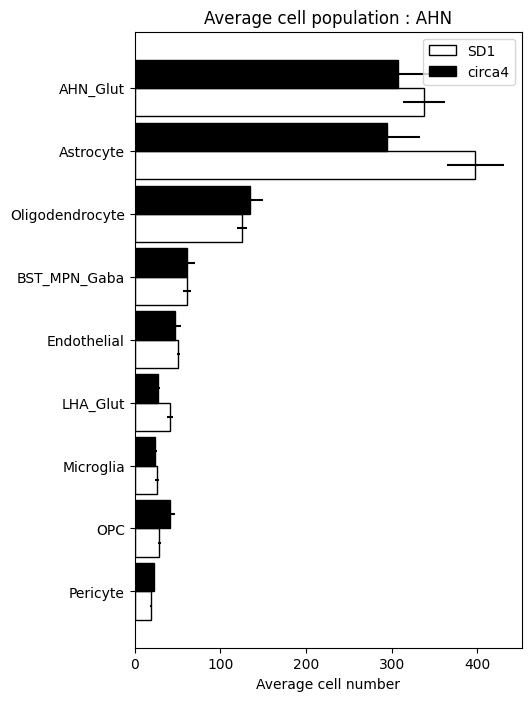

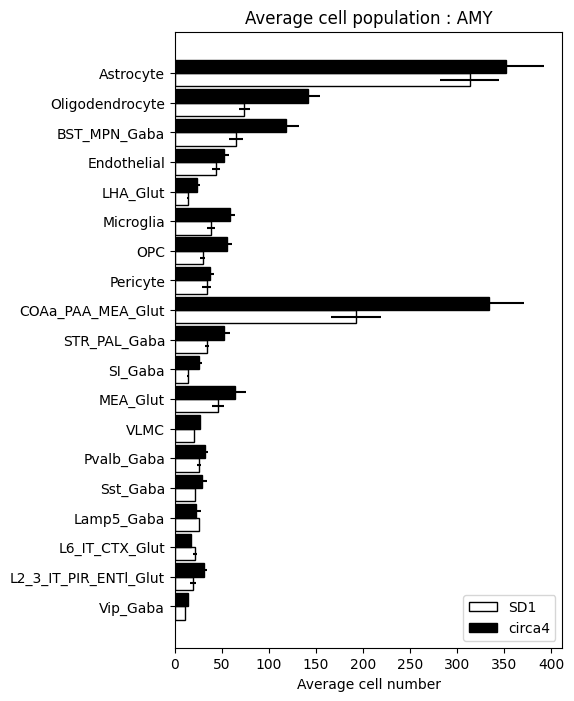

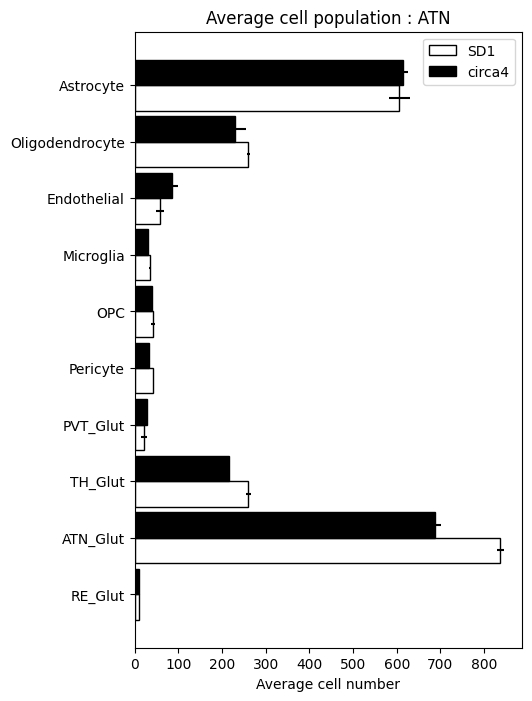

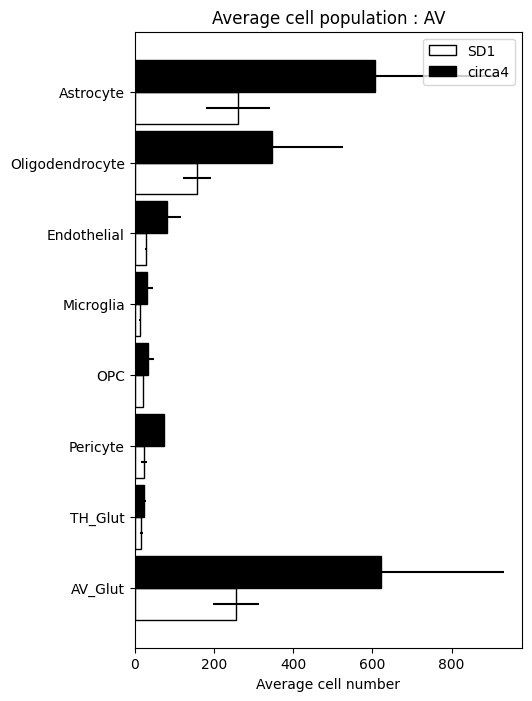

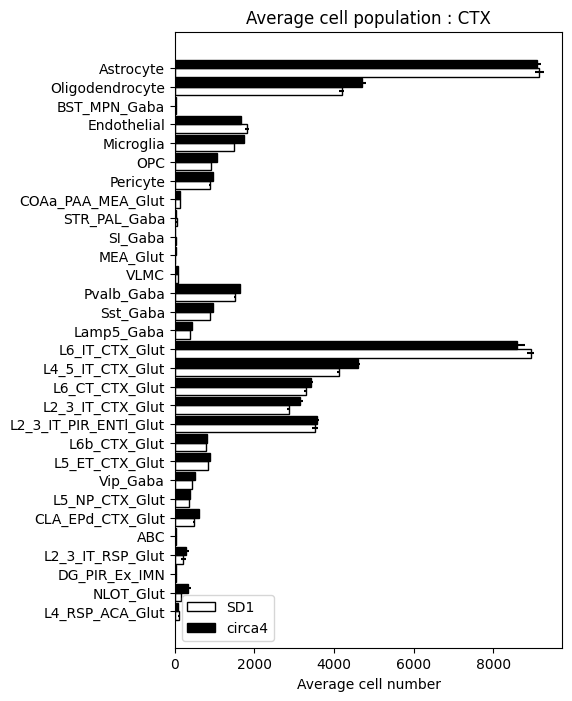

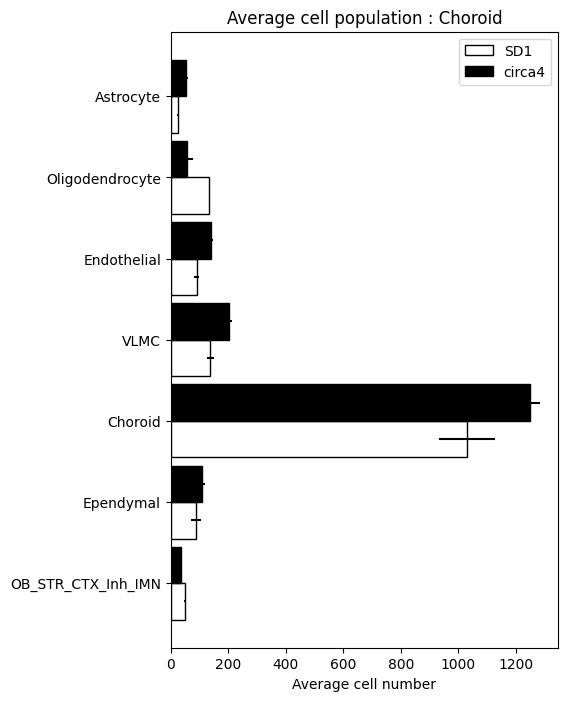

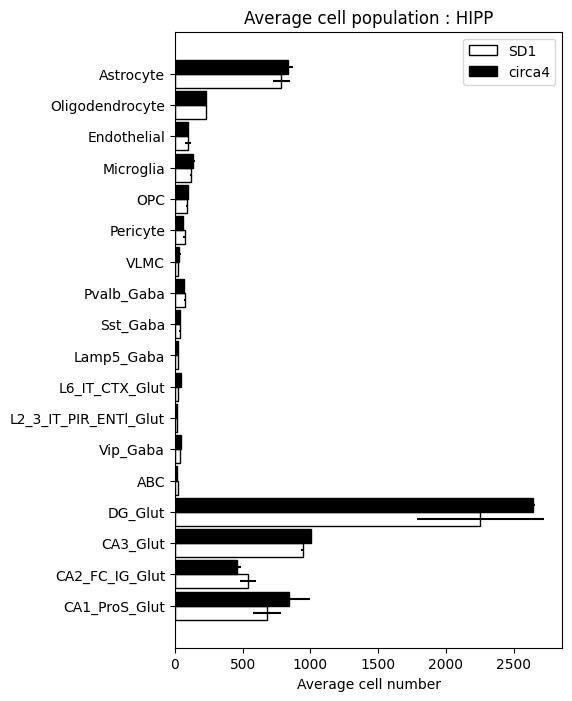

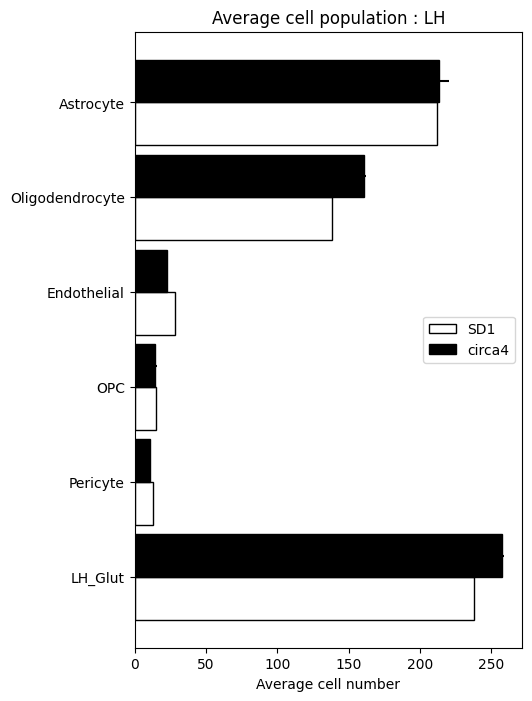

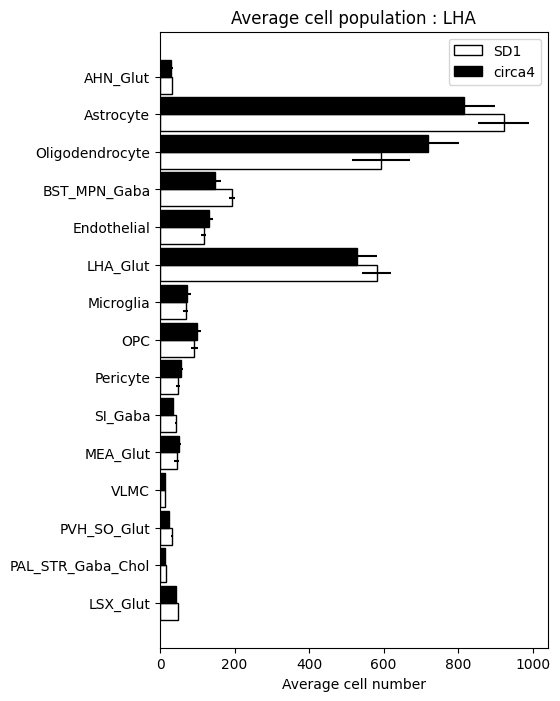

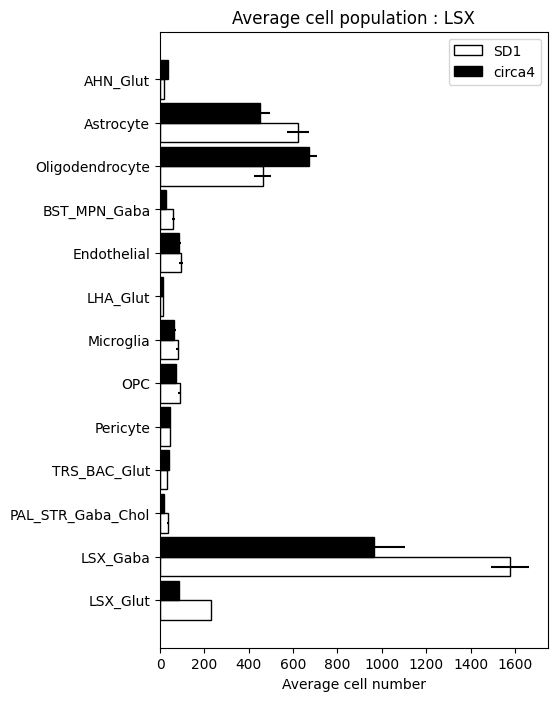

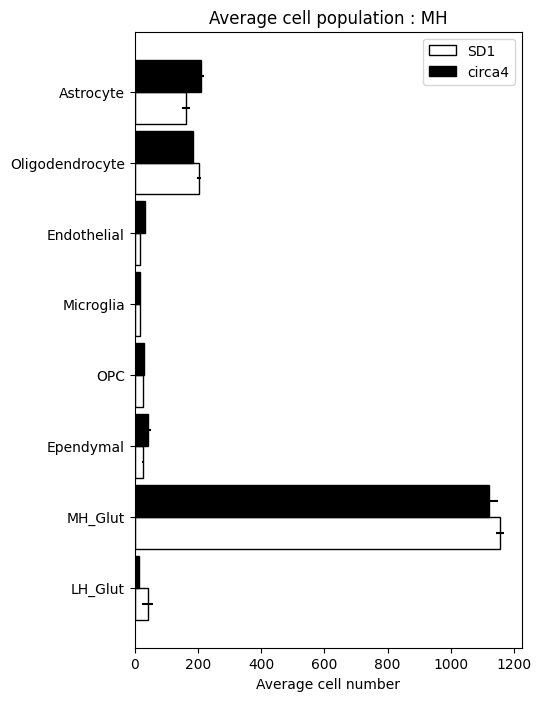

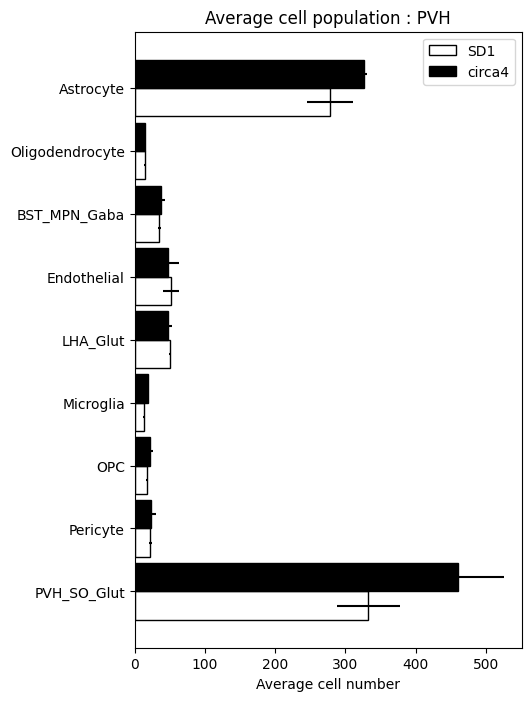

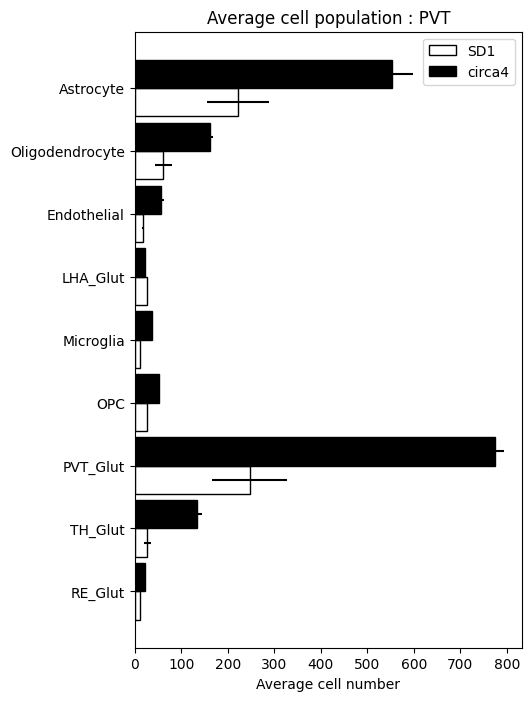

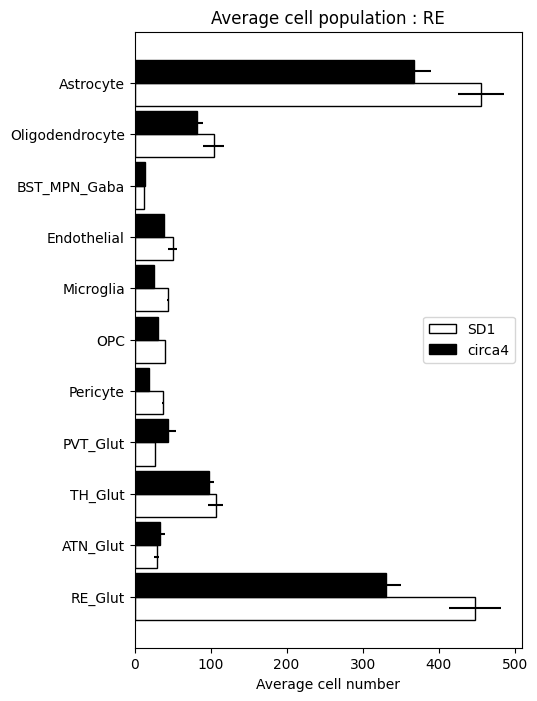

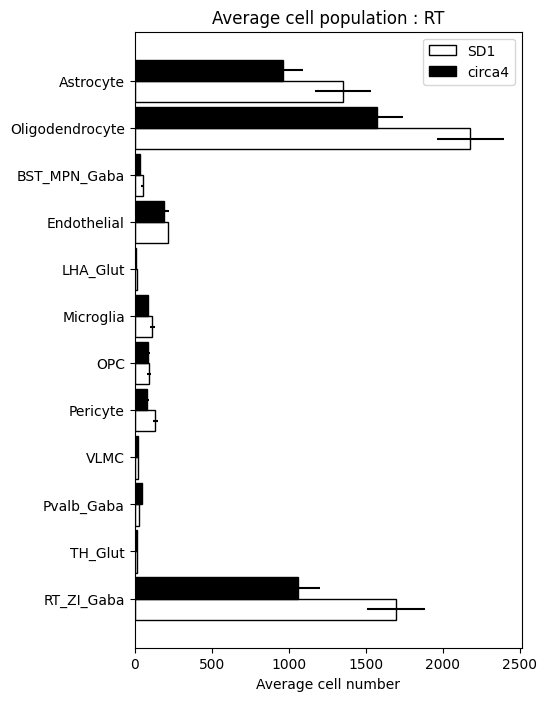

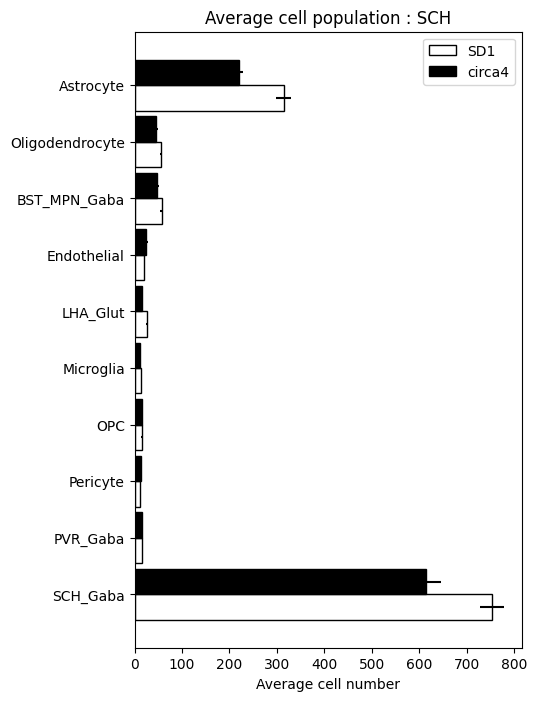

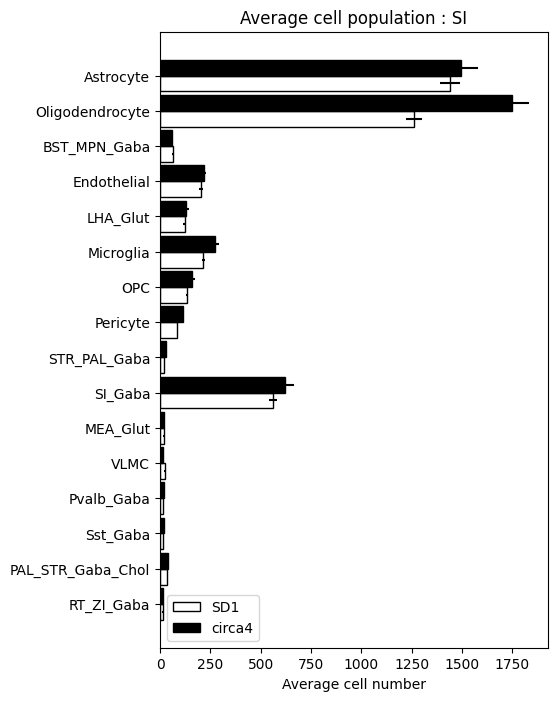

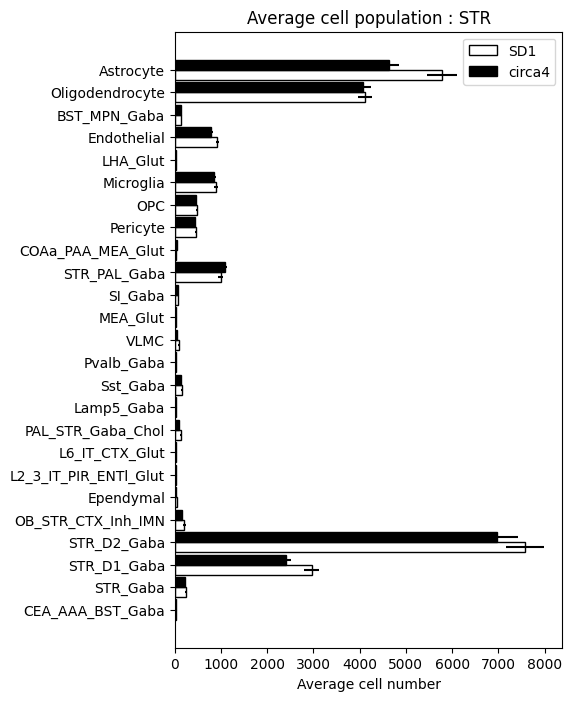

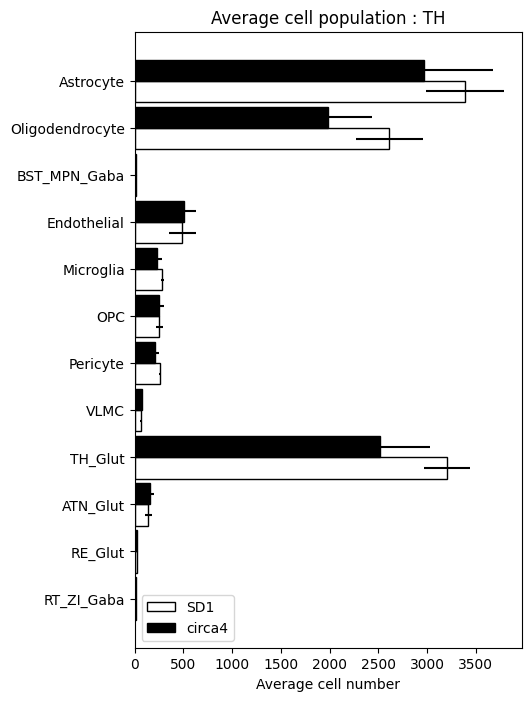

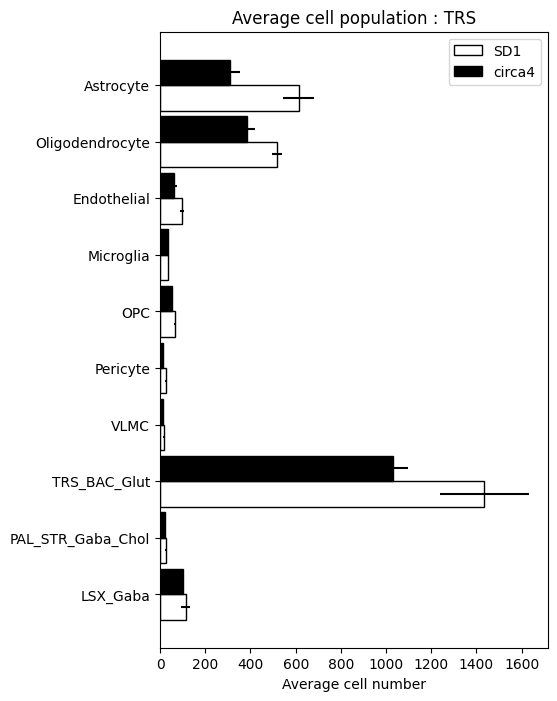

In [45]:
group = ['SD1','circa4']

for key in df_pct.keys():
    if key == 'PT':
        continue
    elif key == 'Tanycyte':
        continue
    elif key == 'B':
        continue
    elif key == 'A':
        continue
    elif key == 'BST':
        continue
    elif key == 'AD':
        continue
    print(key)
    df_average[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_average[key].columns]
    df_average[key].index = group
    df_std[key].index = group

    plt.figure(figsize=(5,8))
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T[group[0]],
           height= 0.45, align='edge', label = group[0],edgecolor='black',color = 'white',
           xerr= df_std[key].T[group[0]] )
    
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T[group[1]],
           height= -0.45, align='edge', label = group[1],edgecolor='black', color = 'black',
           xerr= df_std[key].T[group[1]]
           )

    plt.gca().invert_yaxis()

    plt.xlabel('Average cell number')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig(f'Gallery/{today}/celltype_region/{name_dir}_cellnb_{key}.svg')
    clear_output()

In [ ]:
len(df_pct[key])

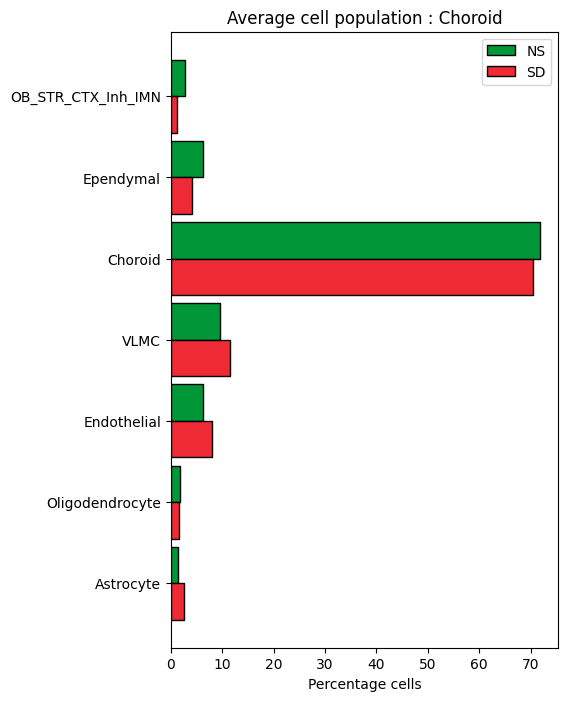

In [46]:
for key in ['Choroid']:
    if len(df_pct[key]) == 1:
        continue
    df_pct[key] = df_pct[key][df_pct[key].select_dtypes(np.number).gt(0.5)]
    df_pct[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_pct[key].columns]
    df_pct[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           )
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           )
    plt.xlabel('Percentage cells')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

# Cell population dendro order

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
cell_nb = pd.read_csv(f'{dir_notebook}/analysis/{name_dir}/summary_cell_number.csv')
cell_nb.sample()

In [ ]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb.sample()

cell_nb["Celltype_order"] = pd.Categorical(cell_nb['cell_type_final'], categories=order_list, ordered = True)
cell_nb.sort_values('Celltype_order', inplace= True)

In [ ]:
param = 'run'
group1 = "circa4"
group2 = 'SD1'

plt.figure(figsize=(2,10))
plt.barh(y=cell_nb['cell_type_final'][cell_nb[param]==group1],
         width=cell_nb[cell_nb[param]==group1]['count'],
           height = 0.5, align='edge', edgecolor ='black')
plt.barh(y=cell_nb['cell_type_final'][cell_nb[param]==group2],
         width=cell_nb[cell_nb[param]==group2]['count'],
           height= -0.5, align='edge', edgecolor ='black')
plt.yticks(ticks=cell_nb['cell_type_final'][cell_nb[param]==group2], rotation=0)
plt.xscale('log')
plt.savefig(f'Gallery/{today}/{name_dir}_cellnb.svg')

## Cell pop hierarchical order

In [ ]:
df = df[~(df['cell_type_final'] == 'Undefined')]
# df = df[~(df['cell_type_final'] == 'AD Glut')]

In [ ]:
cell_pop = df.groupby(['cell_type_final','run'])["ZT"].count()
cell_pop.head()

In [ ]:
# cell_pop = pd.read_csv(f'../notebook/analysis/{name_dir}/{name_dir}_cellpop.csv')
# circa_pct = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_circa-percent.csv')

In [ ]:
cell_pop = pd.DataFrame(data = {"cell_type_final" : cell_pop.index,
                                "count" : cell_pop.values})
# cell_pop.rename(columns={"ZT" : "count"})


In [ ]:
from module.misc import cell_class

cell_pop[['celltype','genotype']] = cell_pop['cell_type_final'].apply(pd.Series)

class_dict = cell_class()
cell_pop['cell_class'] = 'Neuron'
cell_pop['cell_class'] = cell_pop['celltype'].map(class_dict)
cell_pop['cell_class'] = cell_pop['cell_class'].fillna('Neuron')

cell_pop

In [ ]:
# cell_pop['cell_type_final'] = cell_pop.index
cell_pop.sort_values(by='cell_type_final', inplace=True, ignore_index=True)
# circa_pct.sort_values(by='cell_type_final', inplace=True, ignore_index=True)


In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k')
df_CG = df.filter(clock_genes, axis = 1)

In [ ]:
df_CG['cell_type_final'] = df['cell_type_final']
df_CG.sample() 

In [ ]:
grouped = df.groupby('cell_type_final')[clock_genes].mean()

In [ ]:
order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']

# order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']



# cell_pop["Celltype_order"] = pd.Categorical(cell_pop["cell_type_final"], categories=order_list, ordered = True)
cell_pop["Celltype_order"] = pd.Categorical(cell_pop["celltype"], categories=order_list, ordered = True)

cell_pop.sort_values('Celltype_order', inplace= True)

# grouped_sort = grouped.reindex(order_list)
# grouped_sort

In [ ]:
cell_pop.head()

In [ ]:
### One bar for all
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=cell_pop['cell_type_final'],
         width=cell_pop['count'],
           height = 0.8, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(cell_pop))


# plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

In [ ]:
### One bar epr genotype
import seaborn as sns



temp = cell_pop#[cell_pop['cell_class']=="Neuron"]
# temp.sort_values(by="count", inplace = True)

plt.figure(figsize=(2,10))

plt.barh(y=temp[temp['genotype']==group1]['celltype'],
         width=temp[temp['genotype']==group1]['count'],
           height = 0.4, align='edge', edgecolor ='black')
plt.barh(y=temp[temp['genotype']==group2]['celltype'],
         width=temp[temp['genotype']==group2]['count'],
           height = -0.4, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(temp)/2)


plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

# Expressed genes

In [17]:
df.columns

Index(['2010300C02Rik', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1',
       'Adgrl4', 'Aldh1a2', 'Angpt1', 'Ano1',
       ...
       'Zfp536', 'Zfpm2', 'cell_id', 'sample', 'ZT', 'Genotype',
       'cell_type_final', 'region_automap_name', 'x_centroid', 'y_centroid'],
      dtype='object', length=255)

In [7]:
df_NS = df[(df['run']=='circa4')]
df_SD = df[(df['run']=='SD1')]
del df

In [71]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')
NS_dict_pos = {}
mean_expr = df_NS.groupby('cell_type_final')[clock_genes].mean()
expr_frac = df_NS[clock_genes].gt(0).groupby(df_NS['cell_type_final']).mean()

gene_columns = df_NS[clock_genes]
grouped = df_NS.groupby('cell_type_final')


for cell_type, group in grouped:
    # group.reindex()
    gene_presence_pct = group[clock_genes].mean()
    gene_pct = group[clock_genes].gt(0).mean()
    expressed_genes = gene_presence_pct[((gene_presence_pct >= 0.01) & (gene_pct >= 0.1))].index.tolist()
    NS_dict_pos[cell_type] = expressed_genes

NS_dict_nb_gene = {}

for key in NS_dict_pos.keys():
    NS_dict_nb_gene[key]=len(NS_dict_pos[key])
NS_dict_nb_gene


: 

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')
SD_dict_pos = {}
mean_expr = df_SD.groupby('cell_type_final')[clock_genes].mean()
expr_frac = df_SD[clock_genes].gt(0).groupby(df_SD['cell_type_final']).mean()

gene_columns = df_SD[clock_genes]
grouped = df_SD.groupby('cell_type_final')


for cell_type, group in grouped:
    # group.reindex()
    gene_presence_pct = group[clock_genes].mean()
    gene_pct = group[clock_genes].gt(0).mean()
    expressed_genes = gene_presence_pct[((gene_presence_pct >= 0.01) & (gene_pct >= 0.1))].index.tolist()
    NS_dict_pos[cell_type] = expressed_genes

SD_dict_nb_gene = {}

for key in SD_dict_pos.keys():
    SD_dict_nb_gene[key]=len(SD_dict_pos[key])
SD_dict_nb_gene


In [11]:
gene_nb = [len(dict_pos[key]) for key in NS_dict_pos.keys()]
gene_nb

[730,
 823,
 906,
 452,
 1244,
 662,
 471,
 528,
 234,
 1229,
 231,
 630,
 884,
 1152,
 881,
 435,
 612,
 463,
 788,
 464,
 1294,
 1181,
 780,
 1272,
 863,
 1086,
 659,
 1198,
 1130,
 759,
 1109,
 915,
 378,
 479,
 760,
 678,
 171,
 528,
 883,
 1097,
 760,
 522,
 1023,
 1023,
 886,
 644,
 1217,
 816,
 565,
 881,
 909,
 840,
 709,
 920,
 993,
 1085,
 750,
 1021,
 1054,
 949,
 515,
 631,
 1374]

In [25]:
# ertg = pd.DataFrame(data={"NS":dict_nb_gene.values()}, index = dict_nb_gene.keys())
ertg['SF'] = dict_nb_gene.values()

In [26]:
ertg

,NS,SF
ABC,730,312
AD_Glut,823,1031
AHN_Glut,906,1019
ATN_Glut,452,672
AV_Glut,1244,574
Astrocyte,662,74
BST_MPN_Gaba,471,942
BST_po_Glut,528,895
CA1_ProS_Glut,234,181
CA2_FC_IG_Glut,1229,172


In [ ]:
gene_nb.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

# Ratio of cell expressing genes

In [ ]:
# NS
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="circa4"]['pct_nz_group'][clock].values

In [ ]:
import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes_otherrange.svg',dpi=300)

In [ ]:
# SF
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="SD1"]['pct_nz_group'][clock].values

import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
plt.savefig(f'Gallery/{today}/SF_corr_cyclinggenes_ordernbcycgenes_otherrange.svg',dpi=300)

In [21]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k_circa')

In [24]:
df[clock_genes].quantile(0.25)

A1cf      0.0
A2m       0.0
Aatf      0.0
Abca1     0.0
Abca13    0.0
         ... 
Zswim9    0.0
Zup1      0.0
Zyx       0.0
Zzef1     0.0
a         0.0
Name: 0.25, Length: 4655, dtype: float64